In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

**1. Data Loading and Exploration:**

In [2]:
mobile = pd.read_csv('train.csv')
mobile.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
# Data types
mobile.dtypes

,0
battery_power,int64
blue,int64
clock_speed,float64
dual_sim,int64
fc,int64
four_g,int64
int_memory,int64
m_dep,float64
mobile_wt,int64
n_cores,int64


In [4]:
mobile.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


**2. Data Cleaning and Preprocessing:**

- Address missing or null values.

In [5]:
# Verify the missing values
mobile.isnull().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


There are no missing values in the dataset. We can explore the data.

In [6]:
# Count unique values per column
# This helps identify categorical vs. continuous features.
# If a column has very few unique values, it might be a categorical feature
mobile.nunique()

,0
battery_power,1094
blue,2
clock_speed,26
dual_sim,2
fc,20
four_g,2
int_memory,63
m_dep,10
mobile_wt,121
n_cores,8


- Transform categorical data into numerical format using suitable methods.

In [7]:
mobile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

The dataset already represents **categorical data numerically**.
With *'mobile.dtypes'* we have seen that the columns are either int64 or float64. So there is no additional transformations needed.  

**3. Statistical Analysis with NumPy and SciPy:**

- Execute detailed statistical analysis on each feature

- - Calculation of central tendency measures (mean, median, mode).

In [8]:
mean = mobile.mean()
median = mobile.median()
mode = mobile.mode().iloc[0] # # Taking the first mode if multiple exist
# mode is the most frequent value in the dataset

df_mobile = pd.DataFrame({'Mean': mean,
                          'Median': median,
                          'Mode': mode})
df_mobile

,Mean,Median,Mode
battery_power,1238.51850,1226.0,618.0
blue,0.49500,0.0,0.0
clock_speed,1.52225,1.5,0.5
dual_sim,0.50950,1.0,1.0
fc,4.30950,3.0,0.0
four_g,0.52150,1.0,1.0
int_memory,32.04650,32.0,27.0
m_dep,0.50175,0.5,0.1
mobile_wt,140.24900,141.0,182.0
n_cores,4.52050,4.0,4.0


- - Analysis of variability (range, variance, standard deviation).

In [9]:
df_mobile['Range'] = mobile.max() - mobile.min() # gives the spread of data
df_mobile['Variance'] = mobile.var()
df_mobile['Standard Deviation'] = mobile.std()
df_mobile

,Mean,Median,Mode,Range,Variance,Standard Deviation
battery_power,1238.51850,1226.0,618.0,1497.0,1.930884e+05,439.418206
blue,0.49500,0.0,0.0,1.0,2.501001e-01,0.500100
clock_speed,1.52225,1.5,0.5,2.5,6.658629e-01,0.816004
dual_sim,0.50950,1.0,1.0,1.0,2.500348e-01,0.500035
fc,4.30950,3.0,0.0,19.0,1.884813e+01,4.341444
four_g,0.52150,1.0,1.0,1.0,2.496626e-01,0.499662
int_memory,32.04650,32.0,27.0,62.0,3.292670e+02,18.145715
m_dep,0.50175,0.5,0.1,0.9,8.318353e-02,0.288416
mobile_wt,140.24900,141.0,182.0,120.0,1.253136e+03,35.399655
n_cores,4.52050,4.0,4.0,7.0,5.234197e+00,2.287837


- - Evaluation of distribution shapes through skewness and kurtosis.

- **Skewness:**
  - > 0: Right-skewed (tail extends to the right)
  - < 0: Left-skewed (tail extends to the left)
  - ≈ 0: Symmetric distribution

- **Kurtosis:**
  - > 3: Leptokurtic (high peak, heavy tails)
  - ≈ 3: Mesokurtic (normal distribution)
  - < 3: Platykurtic (flat distribution, light tails)

In [10]:
from scipy.stats import skew, kurtosis

skewness =skew(mobile)
kurtosis = kurtosis(mobile)

df_mobile['Skewness'] = skewness
df_mobile['Kurtosis'] = kurtosis
df_mobile

,Mean,Median,Mode,Range,Variance,Standard Deviation,Skewness,Kurtosis
battery_power,1238.51850,1226.0,618.0,1497.0,1.930884e+05,439.418206,0.031875,-1.224084
blue,0.49500,0.0,0.0,1.0,2.501001e-01,0.500100,0.020001,-1.999600
clock_speed,1.52225,1.5,0.5,2.5,6.658629e-01,0.816004,0.177951,-1.323109
dual_sim,0.50950,1.0,1.0,1.0,2.500348e-01,0.500035,-0.038007,-1.998555
fc,4.30950,3.0,0.0,19.0,1.884813e+01,4.341444,1.019046,0.273386
four_g,0.52150,1.0,1.0,1.0,2.496626e-01,0.499662,-0.086080,-1.992590
int_memory,32.04650,32.0,27.0,62.0,3.292670e+02,18.145715,0.057846,-1.216034
m_dep,0.50175,0.5,0.1,0.9,8.318353e-02,0.288416,0.089015,-1.274164
mobile_wt,140.24900,141.0,182.0,120.0,1.253136e+03,35.399655,0.006553,-1.210351
n_cores,4.52050,4.0,4.0,7.0,5.234197e+00,2.287837,0.003625,-1.229676


- Perform hypothesis testing for statistical significance between groups (e.g., different price ranges).

In [11]:
mobile['price_range'].nunique()

4

Since the dataset includes a categorical target variable (price_range with 4 levels: 0, 1, 2, 3), we can use ANOVA (Analysis of Variance) to determine if there is a statistically significant difference in means between different price ranges for a given feature.
(ANOVA is used when comparing more than two groups.)

In [12]:
from scipy import stats
import pandas as pd

# Select numerical features for ANOVA test
features = ["battery_power", "ram", "px_height", "px_width", "int_memory", "talk_time"]

anova_results = {}

for feature in features:
    # Split data into groups based on price range (0, 1, 2, 3)
    groups = [mobile[mobile["price_range"] == price][feature] for price in mobile["price_range"].unique()]

    f_stat, p_value = stats.f_oneway(*groups)
    # The *groups syntax unpacks the list, passing each array separately as an argument.

    anova_results[feature] = {"F-statistic": f_stat, "P-value": p_value}

df_anova = pd.DataFrame(anova_results).T # We transpose it, so features are rows and F-statistic, P-value are columns.
df_anova

# Interpretation
alpha = 0.05
# Identify features with significant differences across price ranges
significant_features = df_anova[df_anova["P-value"] < alpha]
print("\nFeatures with significant differences across price ranges:\n", significant_features)



Features with significant differences across price ranges:
                F-statistic       P-value
battery_power    31.598158  5.948688e-20
ram            3520.110824  0.000000e+00
px_height        19.484842  1.886085e-12
px_width         22.620882  2.116911e-14
int_memory        2.922996  3.277694e-02


- If p-value < 0.05, the feature has a significant effect on price range.
- If p-value > 0.05, the feature does not significantly affect price range

- Investigate feature-target correlations using SciPy.

In [13]:
from scipy.stats import pearsonr, spearmanr

# Selecting only numerical features
features = ["battery_power", "ram", "px_height", "px_width", "int_memory", "talk_time"]
target = "price_range"

# Dictionary to store correlation results
correlation_results = {}

# Compute correlation for each feature with price_range
for feature in features:
    # Pearson Correlation (Linear Relationship)
    pearson_corr, _ = pearsonr(mobile[feature], mobile[target])

    # Spearman Correlation (Monotonic Relationship)
    spearman_corr, _ = spearmanr(mobile[feature], mobile[target])

    # Store results
    correlation_results[feature] = {"Pearson": pearson_corr, "Spearman": spearman_corr}

# Convert results to DataFrame for better visualization
correlation_df = pd.DataFrame.from_dict(correlation_results, orient="index")

# Print the results
print("Correlation Results:")
print(correlation_df)


Correlation Results:
                Pearson  Spearman
battery_power  0.200723  0.199991
ram            0.917046  0.917080
px_height      0.148858  0.131884
px_width       0.165818  0.165134
int_memory     0.044435  0.044278
talk_time      0.021859  0.022138


- If high positive **Pearson** correlation (close to +1) → Strong linear relationship.
- If high positive **Spearman** correlation (close to +1) → Strong monotonic relationship.
- A low correlation (close to 0) → Weak or no relationship.

- Apply advanced SciPy statistical functions for deeper insights.


In [14]:
from scipy.stats import shapiro, chi2_contingency

# Shapiro-Wilk Test for Normality
for feature in features:
    statistic, p_value = shapiro(mobile[feature])
    if p_value < 0.05:
        print(f"{feature} does not follow a normal distribution (p = {p_value:.3f})")
    else:
        print(f"{feature} follows a normal distribution (p = {p_value:.3f})")

# Chi2 test for 3G impact on price range
contingency_table = pd.crosstab(mobile['three_g'], mobile['price_range'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

if p < 0.05:
    print("\n3G availability significantly influences price range.")
else:
    print("\n3G availability does NOT significantly influence price range.")

battery_power does not follow a normal distribution (p = 0.000)
ram does not follow a normal distribution (p = 0.000)
px_height does not follow a normal distribution (p = 0.000)
px_width does not follow a normal distribution (p = 0.000)
int_memory does not follow a normal distribution (p = 0.000)
talk_time does not follow a normal distribution (p = 0.000)

3G availability does NOT significantly influence price range.


**4. Data Visualization with Matplotlib:**

In [15]:
# Selecting important features
features = ["battery_power", "ram", "px_height", "px_width", "int_memory", "talk_time"]
target = "price_range"

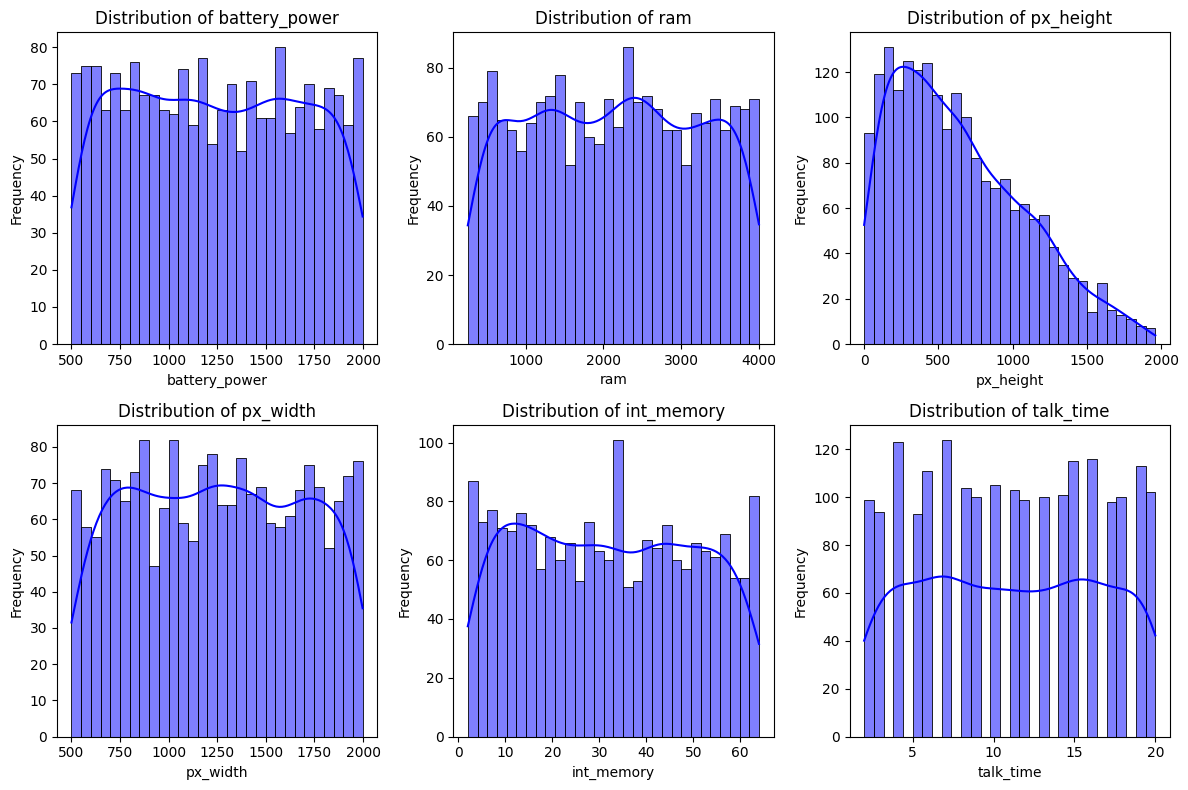

In [16]:
# Show features distributions
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.histplot(mobile[feature], kde=True, color='b', bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout() # adjusts the spacing between subplots to prevent overlapping and ensure they fit nicely within the figure.
plt.show()

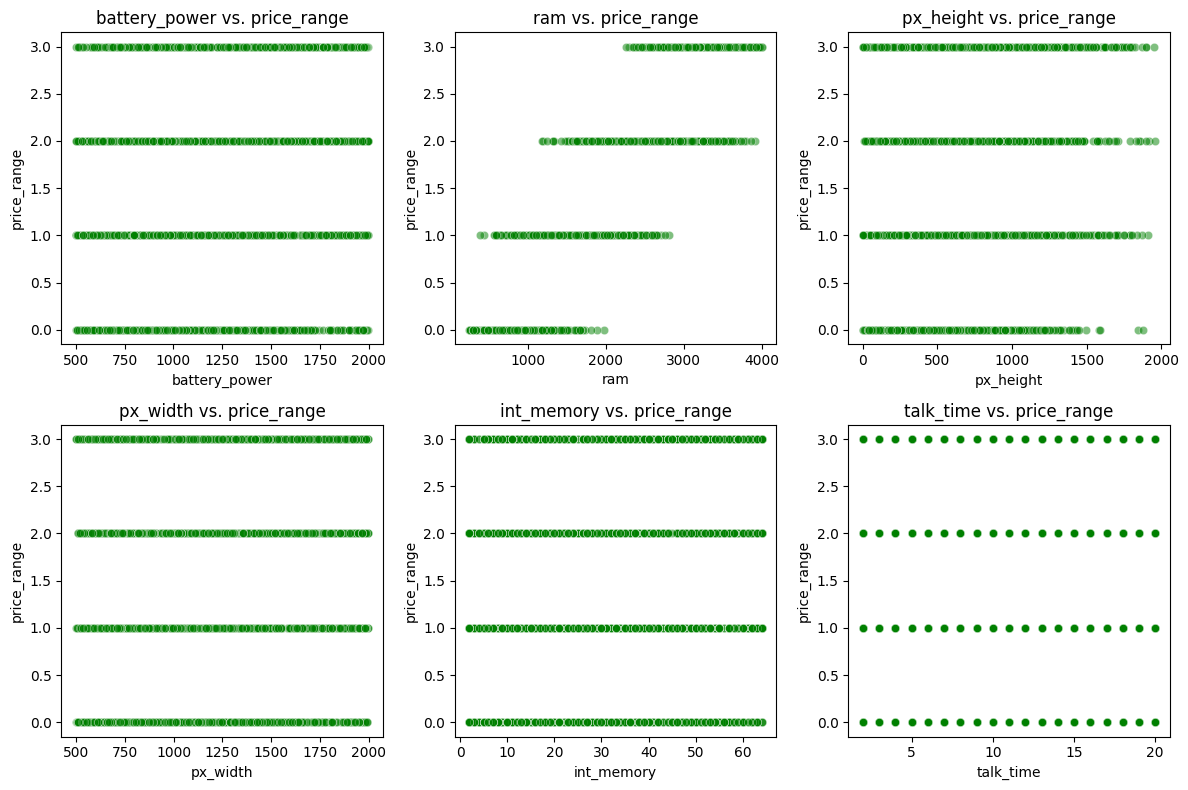

In [17]:
# feature-target relationships

plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.scatterplot(x=mobile[feature], y=mobile[target], color='g', alpha=0.5)
    plt.title(f'{feature} vs. {target}')
    plt.xlabel(feature)
    plt.ylabel(target)
plt.tight_layout()
plt.show()

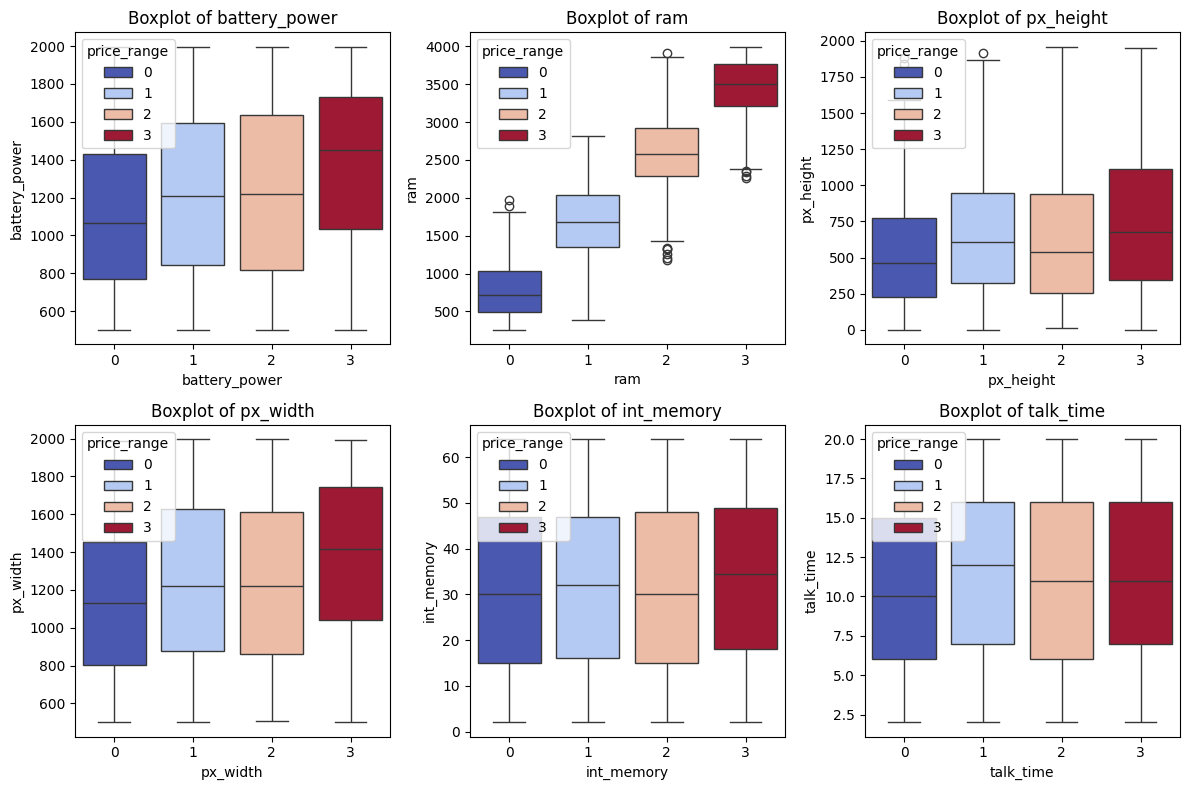

In [18]:
# Identify outliers
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=mobile[target], y=mobile[feature], hue = mobile[target],  palette="coolwarm")
    plt.title(f'Boxplot of {feature}')
    plt.xlabel(feature)
    plt.legend(title=target, loc='upper left')

plt.tight_layout()
plt.show()

**5. Insight Synthesis and Conclusion:**

- **RAM** is the **strongest determinant** of a mobile price.
 - From ANOVA test results, RAM shows the highest impact on price, with an extremely low p-value and the highest F-statistic.
 - RAM has the highest correlation (Pearson & Spearman) (0.91) with price range, meaning that as RAM increases, the phone is more likely to be in a higher price category.
 - RAM has the highest variability, meaning there are large differences in RAM values across different phones.


- **Battery power** and display resolution (**px height & width**) are also important but have less impact compared to RAM.
  - **Pixel width** and **battery power** also show a broad range, indicating diversity in phone specifications.

- **Histogram plots** indicate that most features do not follow a normal distribution.
 - **Battery Power & RAM**: These distributions suggest that most phones have a wide range of battery power and RAM capacities, which might be useful for price predictions.
 - **px_height** shows a clear right-skewed distribution, meaning that most phones have lower pixel heights, and fewer have high px_height values.

 - **Internal memory** and **talk time** do not show a clear trend, indicating they may not be strong price predictors.
  - **Internal memory** and **talk time** show weaker correlations, implying they are less influential in determining price.
  - **Talk time** has the least variability, which means most phones provide a similar talk time range.


**Conclusion :**
- Manufacturers looking to categorize phones into price ranges should prioritize **RAM** size.
- **Battery power** and display resolution (**px height & width**) are also important but have less impact compared to RAM.
- **Talk time** and **internal memory** are weak indicators of price, suggesting that users may not be willing to pay significantly more for longer talk times or higher internal storage.
- Most features do not follow a normal distribution, meaning advanced modeling techniques should consider non-parametric methods or transformations.
